# Machine Learning Modeling

This notebook uses the featurized dataset to create a machine learning model of our binary transition metal oxides to predict stability.

## Steps
1. Load processed features
2. Analyze dataset for stability statistics
3. Standardize features
4. Analyze correlation
5. 5-Fold CV on four models
6. Compare models and find the best
7. Find feature importances
8. Analyze and save results from the best model

## Import packages and load dataset

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                             roc_curve, precision_recall_curve, f1_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path('../data')

# Load dataset
df_features = pd.read_csv(DATA_DIR / 'tm_oxygen_binary_compounds_magpie_features.csv')

print("Dataset loaded!")
print(f"Shape: {df_features.shape}")

# Prepare features
metadata_cols = ['material_id', 'formula', 'transition_metal']
property_cols = ['energy_above_hull', 'volume', 'density', 'band_gap', 'is_stable', 'is_metal']

feature_cols = [col for col in df_features.columns 
                if col not in metadata_cols + property_cols]

X = df_features[feature_cols].copy()

print(f"Features: {X.shape[1]}")
print(f"Samples: {len(X)}")

Dataset loaded!
Shape: (288, 141)
Features: 132
Samples: 288


## Investigating Stability

=== CLASSIFICATION TARGET: Stability ===

Stable (energy = 0): 21
Unstable (energy > 0): 267
Class ratio: 7.3% stable

Class weights (for imbalance):
  Unstable: 0.539
  Stable: 6.857


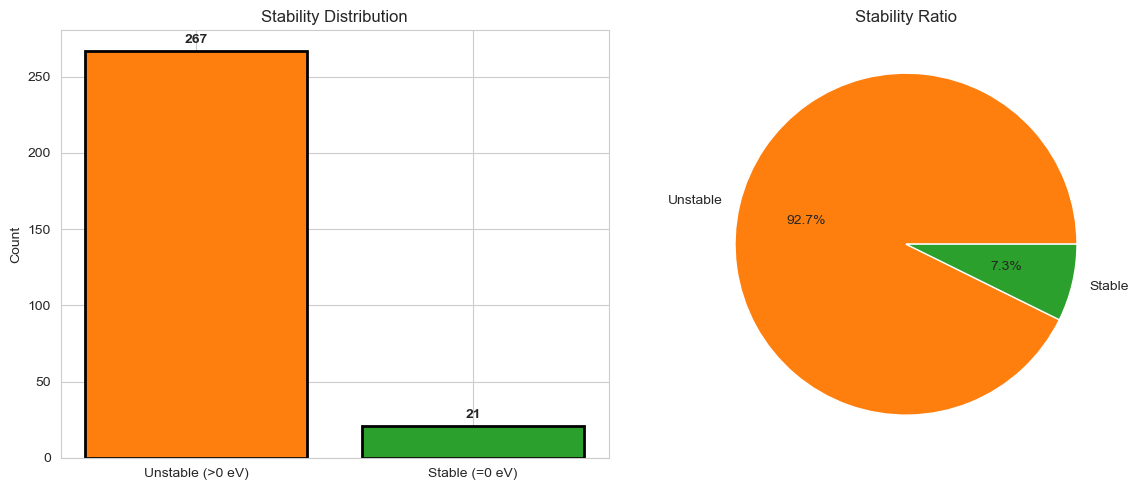

In [26]:
# Create binary stability target: 1 = stable (on convex hull), 0 = unstable
# Using energy_above_hull: 0 eV = stable, > 0 eV = unstable
y_stable = (df_features['energy_above_hull'] == 0).astype(int)

print("=== CLASSIFICATION TARGET: Stability ===\n")
print(f"Stable (energy = 0): {(y_stable == 1).sum()}")
print(f"Unstable (energy > 0): {(y_stable == 0).sum()}")
print(f"Class ratio: {(y_stable == 1).sum() / len(y_stable) * 100:.1f}% stable")

# Check for class imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_stable), y=y_stable)
print(f"\nClass weights (for imbalance):")
print(f"  Unstable: {class_weights[0]:.3f}")
print(f"  Stable: {class_weights[1]:.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
stability_counts = y_stable.value_counts()
axes[0].bar(['Unstable (>0 eV)', 'Stable (=0 eV)'], [stability_counts[0], stability_counts[1]], 
            color=['#ff7f0e', '#2ca02c'], edgecolor='black', linewidth=2)
axes[0].set_ylabel('Count')
axes[0].set_title('Stability Distribution')
for i, v in enumerate([stability_counts[0], stability_counts[1]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie([stability_counts[0], stability_counts[1]], 
            labels=['Unstable', 'Stable'], 
            autopct='%1.1f%%',
            colors=['#ff7f0e', '#2ca02c'])
axes[1].set_title('Stability Ratio')
plt.tight_layout()
plt.savefig("../figures/stability_analysis.png", dpi=100, bbox_inches="tight")
plt.show()

## Standardizing Features

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features standardized!")
print(f"Mean: {X_scaled.mean().mean():.6f}")
print(f"Std: {X_scaled.std().mean():.6f}")

Features standardized!
Mean: -0.000000
Std: 0.743717


## Analyze Correlation

In [28]:
print("=== Top 15 Features Correlated with Stability ===")
correlations = []
for col in X_scaled.columns:
    # Point-biserial correlation for binary classification
    corr = X_scaled[col].corr(y_stable)
    correlations.append((col, corr))

correlations.sort(key=lambda x: abs(x[1]), reverse=True)

for feat, corr in correlations[:15]:
    print(f"  {feat}: {corr:.6f}")

=== Top 15 Features Correlated with Stability ===
  MagpieData minimum Number: nan
  MagpieData mean Number: 0.177004
  MagpieData maximum MendeleevNumber: nan
  MagpieData minimum AtomicWeight: nan
  MagpieData minimum MeltingT: nan
  MagpieData maximum Column: nan
  MagpieData range Column: -0.172555
  MagpieData minimum Column: 0.172555
  MagpieData avg_dev Column: -0.169487
  MagpieData mean AtomicWeight: 0.167777
  MagpieData avg_dev Number: 0.166397
  MagpieData minimum MendeleevNumber: 0.158827
  MagpieData range MendeleevNumber: -0.158827
  MagpieData avg_dev AtomicWeight: 0.158496
  MagpieData avg_dev MendeleevNumber: -0.150764


## 5-Fold CV of Four Models

In [29]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics for classification
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall'
}

# Initialize models with class weights to handle imbalance
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ),
    'Random Forest (Shallow)': RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),
    'Random Forest (Medium)': RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
}

# Run cross-validation for each model
results = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    cv_results = cross_validate(model, X_scaled, y_stable, cv=kfold, 
                                scoring=scoring, return_train_score=True)
    results[model_name] = cv_results

print("\n✓ All models trained!")

Training Logistic Regression...
Training Random Forest (Shallow)...
Training Random Forest (Medium)...
Training Gradient Boosting...

✓ All models trained!


In [30]:
print("=== 5-FOLD CROSS VALIDATION RESULTS ===\n")

for model_name, cv_results in results.items():
    train_acc = cv_results['train_accuracy']
    test_acc = cv_results['test_accuracy']
    train_f1 = cv_results['train_f1']
    test_f1 = cv_results['test_f1']
    train_auc = cv_results['train_roc_auc']
    test_auc = cv_results['test_roc_auc']
    test_precision = cv_results['test_precision']
    test_recall = cv_results['test_recall']
    
    print(f"\n{model_name}:")
    print(f"  Accuracy - Train: {train_acc.mean():.4f} ± {train_acc.std():.4f}")
    print(f"             Test: {test_acc.mean():.4f} ± {test_acc.std():.4f}")
    print(f"  F1 Score - Train: {train_f1.mean():.4f} ± {train_f1.std():.4f}")
    print(f"             Test: {test_f1.mean():.4f} ± {test_f1.std():.4f}")
    print(f"  ROC AUC  - Train: {train_auc.mean():.4f} ± {train_auc.std():.4f}")
    print(f"             Test: {test_auc.mean():.4f} ± {test_auc.std():.4f}")
    print(f"  Precision (Test): {test_precision.mean():.4f} ± {test_precision.std():.4f}")
    print(f"  Recall (Test): {test_recall.mean():.4f} ± {test_recall.std():.4f}")

=== 5-FOLD CROSS VALIDATION RESULTS ===


Logistic Regression:
  Accuracy - Train: 0.8437 ± 0.0228
             Test: 0.7988 ± 0.0563
  F1 Score - Train: 0.4473 ± 0.0385
             Test: 0.2327 ± 0.1055
  ROC AUC  - Train: 0.9287 ± 0.0157
             Test: 0.7027 ± 0.1188
  Precision (Test): 0.2002 ± 0.1559
  Recall (Test): 0.4567 ± 0.2901

Random Forest (Shallow):
  Accuracy - Train: 0.9557 ± 0.0121
             Test: 0.8751 ± 0.0295
  F1 Score - Train: 0.7567 ± 0.0616
             Test: 0.2387 ± 0.1324
  ROC AUC  - Train: 0.9832 ± 0.0080
             Test: 0.7775 ± 0.0883
  Precision (Test): 0.2352 ± 0.1702
  Recall (Test): 0.3400 ± 0.2059

Random Forest (Medium):
  Accuracy - Train: 0.9931 ± 0.0021
             Test: 0.9097 ± 0.0203
  F1 Score - Train: 0.9543 ± 0.0146
             Test: 0.0800 ± 0.1600
  ROC AUC  - Train: 0.9988 ± 0.0009
             Test: 0.7557 ± 0.1113
  Precision (Test): 0.0667 ± 0.1333
  Recall (Test): 0.1000 ± 0.2000

Gradient Boosting:
  Accuracy - Train: 

## Save Data for Visualization and Analysis

In [31]:
summary = []
for model_name, cv_results in results.items():
    summary.append({
        'Model': model_name,
        'Test_Accuracy': cv_results['test_accuracy'].mean(),
        'Test_F1': cv_results['test_f1'].mean(),
        'Test_AUC': cv_results['test_roc_auc'].mean(),
        'Test_Precision': cv_results['test_precision'].mean(),
        'Test_Recall': cv_results['test_recall'].mean(),
    })

df_results = pd.DataFrame(summary)
results_file = DATA_DIR / 'stability_classification_results.csv'
df_results.to_csv(results_file, index=False)
print(f"Saved results to {results_file}\n")
print(df_results.to_string(index=False))

print(f"\n✓ Classification modeling complete!")

Saved results to ../data/stability_classification_results.csv

                  Model  Test_Accuracy  Test_F1  Test_AUC  Test_Precision  Test_Recall
    Logistic Regression       0.798790 0.232731  0.702742        0.200233     0.456667
Random Forest (Shallow)       0.875076 0.238730  0.777504        0.235238     0.340000
 Random Forest (Medium)       0.909679 0.080000  0.755699        0.066667     0.100000
      Gradient Boosting       0.892317 0.088889  0.767667        0.080000     0.100000

✓ Classification modeling complete!
